In [23]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
%matplotlib inline

In [24]:
df= pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'Height')

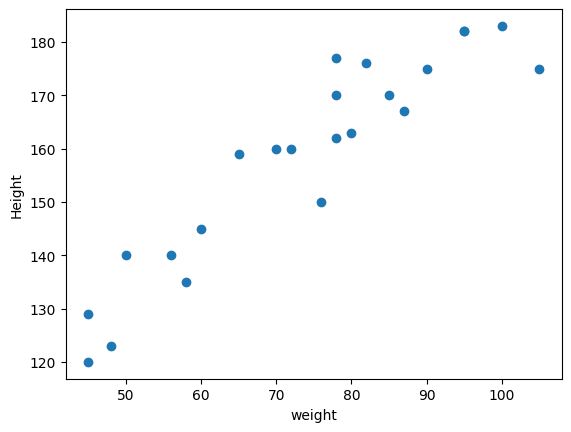

In [25]:
#scatter
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("Height")

In [26]:
##corellation
df.corr() ##uses the pearson corellation

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


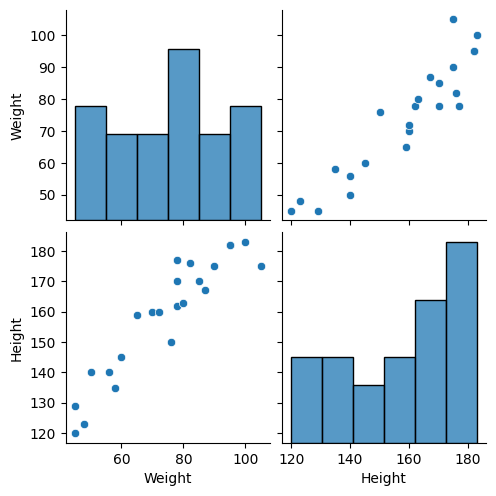

In [27]:
##seaborn for visualization

import seaborn as sns
sns.pairplot(df)

In [28]:
## independ and dependernt features
## independent needs to be in df [[]]
X=df[['Weight']]

##deoendent feature can be in series
y= df['Height']

In [29]:
## train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
X_train.shape

(17, 1)

In [31]:
##standardization sklearn preprocessing
## x in kh y in cm then the values are of diffrent usint but we use gradient decent and maths gets applied to bigger value so it takes time to et to the global
## take each independent feature and apply z score with mean =0  and sd=1 x(i)-mean/sd

from sklearn.preprocessing import StandardScaler

In [32]:
sclaer=StandardScaler()
X_train=sclaer.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [33]:
X_test = sclaer.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [34]:
##apply liner regression 
from sklearn.linear_model import LinearRegression

In [35]:
regression = LinearRegression(n_jobs=-1)

In [36]:
regression.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [37]:
regression.coef_   ##this is the slope


array([17.2982057])

In [38]:
regression.intercept_

np.float64(156.47058823529412)

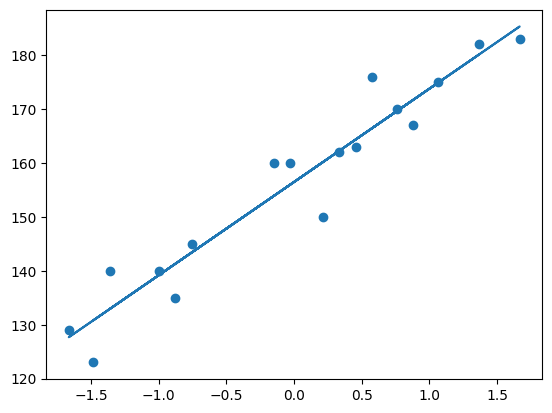

In [39]:
##plot the best fit line
plt.scatter(X_train , y_train)

plt.plot(X_train , regression.predict(X_train))

In [40]:
## prediction of test data

y_pred = regression.predict(X_test)

In [41]:
## performance matrix

from sklearn.metrics import mean_absolute_error , mean_squared_error

In [42]:
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)



114.84069295228699
9.66512588679501
10.716374991212605


In [43]:
from sklearn.metrics import r2_score

score= r2_score(y_test , y_pred)
print(score)



0.7360826717981276


In [46]:
## new data prediction 

regression.predict(sclaer.transform([[89]]))

e:\python bootcamp\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([173.7921725])